## Trabajo Práctico: Redes Neuronales
El objetivo de este trabajo es desarrollar y evaluar modelos basados en redes neuronales,
incorporando técnicas de ablación para entender el impacto de diversas modificaciones en
el proceso de entrenamiento y en la capacidad de generalización del modelo. No se permite
usar librerías de machine learning como scikit-learn o PyTorch, a menos que sea pedido
explícitamente en el enunciado del ejercicio.

### 1. Análisis y Preprocesamiento de Datos
- El dataset que vamos a utilizar es similar a MNIST pero con caracteres japoneses.
- Son imágenes de 28 × 28 con 49 clases posibles.
- Examinar el dataset y visualizar al menos 3 imágenes. 
- Dividir el conjunto de datos en tres subconjuntos: Train, Validation y Test.
- Dividir todos los valores por 255, para que el máximo sea 1.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

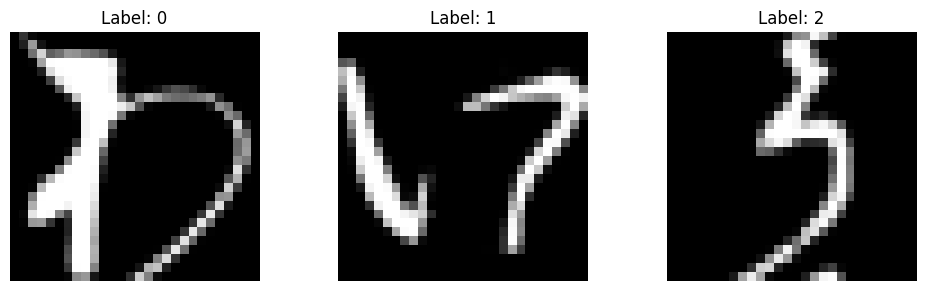

In [8]:
X_images = np.load("data/X_images.npy")
y_images = np.load("data/y_images.npy")

# Select three images with different labels
unique_labels = np.unique(y_images)
selected_images = []
selected_labels = []

for label in unique_labels:
    idx = np.where(y_images == label)[0][0]
    selected_images.append(X_images[idx].reshape(28, 28))
    selected_labels.append(label)
    if len(selected_images) == 3:
        break

# Plot the selected images
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(selected_images[i], cmap='gray')
    ax.set_title(f"Label: {selected_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### 2. Implementación y Entrenamiento de una Red Neuronal Básica
- Implementar una red neuronal con L capas ocultas cada con M (l) nodos con
función de activación ReLU (en las capas ocultas) y activación softmax para la
capa de salida.
- Implementar un algoritmo para entrenar dicha red, mediante backpropagation y
gradiente descendiente estándar, utilizando como función de costo la cross-entropy.
NOTA: El algoritmo backpropagation debe sera adaptado para el caso de clasi-
ficación multi-clase con función de activación softmax para la capa de salida y
función de costo cross-entropy.
- Entrenar una red neuronal con 2 capas ocultas, con 100 y 80 nodos respectiva-
mente, y graficar la evolución de la función de costo (cross-entropy) sobre los
conjuntos de entrenamiento y validación a lo largo de las épocas. Llamaremos a
este modelo M0.
Reportar las siguientes métricas de performance, sobre los conjuntos de entrena-
miento y validación, para el modelo base entrenado:
    - Accuracy
    - Cross-Entropy 
    - Matriz de Confusión